In [1]:
from models import ClimateModel, BaseModel, LinearRegression, BoostingModel, create_nn, MLPModel, RNNModel, CNNModel, LSTMModel, TCNModel, UNetModel, UNet3DModel, load_nn
from train import load_datasets, load_dataset, evaluate_print, evaluate
from experiment import save_experiment, draw_ice_map_rmse, draw_ice_map_corr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dsTest = load_dataset("aice_1_1_1_seq_test")

model2 = BaseModel()
model2.fit(dsTest)
evaluate(dsTest, model2)

,loss,lead_time
0,0.81,3


In [3]:
model2 = BaseModel()
model2.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
evaluate_print(model2, dsTrain, dsTest)

                               Нейросеть, train   0.9817, test   0.9665
                     Несмещенный прогноз, train   0.9581, test   0.9254


In [2]:
#dsTrain, dsTest = load_datasets("aice_1_1_1_seq")
#dsTrain, dsTest = load_datasets("aice_1_2_1_point")
#dsTrain, dsTest = load_datasets("aice_2_2_1_point")
#dsTrain, dsTest = load_datasets("aice_2_2_1_seq")

#model = create_nn('aice', RNNModel, 
    #{'input_size': len(dsTrain.variables), 'hidden_size': 4, 'bidirectional': True},
    #test=dsTest, lr=0.001, epochs=50, verbose=True, seed=42)
#model.fit(dsTrain)

dsTrain, dsTest = load_datasets("aice_2_2_1_map")
model2 = BaseModel()
model2.fit(dsTrain)
evaluate_print(model2, dsTrain, dsTest)

model = create_nn('aice', CNNModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 6 },
    test=dsTest, lr=0.001, epochs=200, verbose=True, seed=42)
_ = model.fit(dsTrain)

evaluate_print(model, dsTrain, dsTest)
evaluate_print(model2, dsTrain, dsTest)


KeyboardInterrupt



In [14]:
dsTrain, dsTest = load_datasets("aice_2_2_1_seqmap")
model2 = BaseModel()
model2.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
evaluate_print(model2, dsTrain, dsTest)

                               Нейросеть, train   0.9467, test   0.9521
                     Несмещенный прогноз, train   0.9509, test   0.9254


In [17]:
#period = 'spring'
period = 'autum'
save_experiment(f'aice_map_{period}', model, dsTest, base=f'aice_base_{period}')

In [33]:
model = load_nn('../data/experiments/aice_mlp_autum')
dsTest2 = load_dataset("aice_1_2_1_point_test")
model2 = BaseModel()
model2.fit(dsTest2)
print(evaluate(dsTest2, model))
print(evaluate(dsTest2, model2))
dsTest3 = load_dataset("aice_2_2_1_point_test")
print(evaluate(dsTest3, model))
print(evaluate(dsTest3, model2))

    loss  lead_time
0  0.257          3
     loss  lead_time
0  0.8236          3
     loss  lead_time
0  0.9605          3
     loss  lead_time
0  0.9254          3


In [26]:
model2 = BaseModel()
model2.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
evaluate_print(model2, dsTrain, dsTest)

                               Нейросеть, train   0.7747, test   0.8161
                     Несмещенный прогноз, train   0.7201, test   0.8100


In [9]:
model = create_nn('aice', RNNModel, 
    {'input_size': len(dsTrain.variables), 'hidden_size': 16, 'bidirectional': True},
    test=dsTest, lr=0.001, epochs=30, verbose=True, seed=42)
model.fit(dsTrain)

model2 = BaseModel()
model2.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
evaluate_print(model2, dsTrain, dsTest)

1

In [4]:
model.epochs += 200
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
evaluate_print(model2, dsTrain, dsTest)

Epoch 101, train loss:   0.0333, test loss:   0.8262, time: 0.67s
Epoch 102, train loss:   0.0332, test loss:   0.8259, time: 0.47s
Epoch 103, train loss:   0.0332, test loss:   0.8246, time: 0.47s
Epoch 104, train loss:   0.0333, test loss:   0.8265, time: 0.47s
Epoch 105, train loss:   0.0331, test loss:   0.8260, time: 0.47s
Epoch 106, train loss:   0.0332, test loss:   0.8241, time: 0.46s
Epoch 107, train loss:   0.0333, test loss:   0.8269, time: 0.46s
Epoch 108, train loss:   0.0331, test loss:   0.8261, time: 0.46s
Epoch 109, train loss:   0.0333, test loss:   0.8228, time: 0.46s
Epoch 110, train loss:   0.0335, test loss:   0.8279, time: 0.46s
Epoch 111, train loss:   0.0332, test loss:   0.8262, time: 0.47s
Epoch 112, train loss:   0.0334, test loss:   0.8211, time: 0.46s
Epoch 113, train loss:   0.0336, test loss:   0.8288, time: 0.47s
Epoch 114, train loss:   0.0333, test loss:   0.8263, time: 0.46s
Epoch 115, train loss:   0.0333, test loss:   0.8210, time: 0.47s
Epoch 116,

KeyboardInterrupt: 

In [6]:
dsTest2 = load_dataset("aice_1_2_1_seq_test")
model2 = BaseModel()
model2.fit(dsTest2)
print(evaluate(dsTest2, model))
print(evaluate(dsTest2, model2))
dsTest3 = load_dataset("aice_2_2_1_seq_test")
print(evaluate(dsTest3, model))
print(evaluate(dsTest3, model2))

     loss  lead_time
0  0.7787          3
   loss  lead_time
0  0.81          3
     loss  lead_time
0  0.9683          3
     loss  lead_time
0  0.9246          3


In [12]:
save_experiment('aice_mlp_autum', model, dsTest, base='aice_base_autum')

In [15]:
dsTrain, dsTest = load_datasets("aice_1_2_1_point")
save_experiment('aice_mlp_spring', model, dsTest)
dsTrain, dsTest = load_datasets("aice_2_2_1_point")
save_experiment('aice_mlp_autum', model, dsTest)

D:\weather\arpp\scripts\..\data\experiments\aice_mlp_spring_rmse.png
D:\weather\arpp\scripts\..\data\experiments\aice_mlp_spring_corr.png


TypeError: unsupported operand type(s) for +: 'WindowsPath' and 'str'

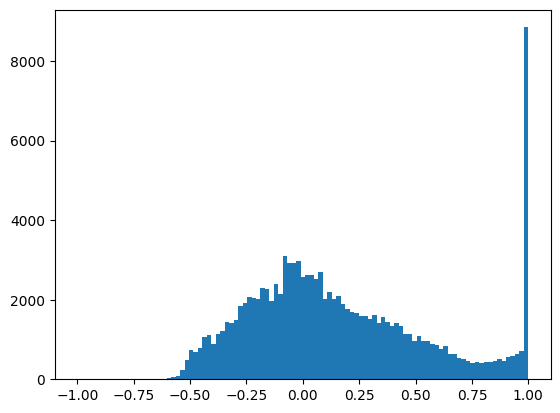

In [6]:
plt.hist(data.ravel(), 101)
plt.show()

In [2]:
dsTrain, dsTest = load_datasets("swe_2_2_2_point")
model = BaseModel()
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
save_experiment('swe_base_autum_lead_time_1', model, dsTest)

                     Несмещенный прогноз, train   0.0857, test   0.2125


In [4]:
dsTrain, dsTest = load_datasets("swe_1_2_2_point")
model = BaseModel()
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
save_experiment('swe_base_spring_lead_time_1', model, dsTest)

                     Несмещенный прогноз, train   0.1055, test   0.1098


In [5]:
dsTrain, dsTest = load_datasets("swe_1_1_1_point")
model = BaseModel()
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
save_experiment('swe_base_spring', model, dsTest)

                     Несмещенный прогноз, train   0.0466, test   0.0245


In [2]:
#dsTrain, dsTest = load_datasets("swe_2_2_1_seqmap")
model2 = BaseModel()
model2.fit(dsTest)
print(evaluate(dsTest, model2))
model = create_nn('swe', UNet3DModel, 
    {'input_channels': len(dsTrain.variables), 'base_channels': 16 },
    test=dsTest, lr=0.0001, epochs=120, verbose=True, seed=42)
_ = model.fit(dsTrain)

     loss  lead_time
0  0.1165          3
Batch   10,   6.8312
Batch   20,   6.4474
Batch   30,   6.5332
Batch   40,   6.4838
Batch   50,   6.4361
Batch   60,   6.4308
Batch   70,   6.4135
Epoch   1, train loss:   6.4135, test loss:   0.1322, time: 126.62s
Epoch   2, train loss:   6.4224, test loss:   0.1427, time: 30.16s
Epoch   3, train loss:   6.3958, test loss:   0.1733, time: 14.95s
Epoch   4, train loss:   6.3880, test loss:   0.1748, time: 14.15s
Epoch   5, train loss:   6.3457, test loss:   0.1892, time: 14.04s
Epoch   6, train loss:   6.3488, test loss:   0.1989, time: 14.08s
Epoch   7, train loss:   6.3322, test loss:   0.2013, time: 14.17s
Epoch   8, train loss:   6.3292, test loss:   0.2040, time: 14.15s
Epoch   9, train loss:   6.3125, test loss:   0.2040, time: 14.16s
Epoch  10, train loss:   6.3106, test loss:   0.2049, time: 14.15s
Epoch  11, train loss:   6.2999, test loss:   0.2063, time: 14.22s
Epoch  12, train loss:   6.2988, test loss:   0.2068, time: 14.14s
Epoch 


KeyboardInterrupt



In [3]:
#dsTest2 = load_dataset("swe_1_2_1_seq_test")
#print(evaluate(dsTest2, model))
#print(evaluate(dsTest2, model2))
print(evaluate(dsTest, model))
print(evaluate(dsTest, model2))

#save_experiment('swe_rnn_spring', model, dsTest2, base="swe_base_spring")
save_experiment('swe_seqmap_autum', model, dsTest, base="swe_base_autum")

     loss  lead_time
0  0.2045          3
     loss  lead_time
0  0.1165          3


In [9]:
#model = create_nn('swe', TCNModel, 
#    {'input_size': len(dsTrain.variables), 'channels': [16, 16], 'kernel_size': 3 },
#    test=dsTest, lr=0.0002, epochs=40, verbose=True, seed=42)
model.epochs += 50
_ = model.fit(dsTrain)
#_ = model.fit(dsTrain)
#evaluate_print(model, dsTrain, dsTest)
#evaluate_print(model2, dsTrain, dsTest)

Epoch 121, train loss:   6.9094, test loss:   0.2548, time: 2.96s
Epoch 122, train loss:   6.8258, test loss:   0.2596, time: 2.70s
Epoch 123, train loss:   6.8334, test loss:   0.2546, time: 2.70s
Epoch 124, train loss:   6.8513, test loss:   0.2570, time: 2.71s
Epoch 125, train loss:   6.7992, test loss:   0.2562, time: 2.71s
Epoch 126, train loss:   6.8542, test loss:   0.2565, time: 2.71s
Epoch 127, train loss:   6.9044, test loss:   0.2546, time: 2.71s
Epoch 128, train loss:   6.8551, test loss:   0.2606, time: 2.71s
Epoch 129, train loss:   6.8500, test loss:   0.2532, time: 2.71s
Epoch 130, train loss:   6.8714, test loss:   0.2577, time: 2.71s
Epoch 131, train loss:   6.7881, test loss:   0.2570, time: 2.72s
Epoch 132, train loss:   6.8005, test loss:   0.2565, time: 2.75s
Epoch 133, train loss:   6.8583, test loss:   0.2514, time: 2.71s
Epoch 134, train loss:   6.7793, test loss:   0.2601, time: 2.71s
Epoch 135, train loss:   6.7866, test loss:   0.2527, time: 2.72s
Epoch 136,

In [ ]:
dsTest2 = load_dataset("swe_1_2_1_point_test")
model2 = BaseModel()
model2.fit(dsTest2)
print(evaluate(dsTest2, model))
print(evaluate(dsTest2, model2))
dsTest3 = load_dataset("swe_2_2_1_point_test")
print(evaluate(dsTest3, model))
print(evaluate(dsTest3, model2))

In [7]:
dsTest2 = load_dataset("swe_1_2_1_point_test")
model2 = BaseModel()
model2.fit(dsTest2)
print(evaluate(dsTest2, model))
print(evaluate(dsTest2, model2))
dsTest3 = load_dataset("swe_2_2_1_point_test")
print(evaluate(dsTest3, model))
print(evaluate(dsTest3, model2))

     loss  lead_time
0  0.1573          3
     loss  lead_time
0  0.0245          3
     loss  lead_time
0  0.2412          3
     loss  lead_time
0  0.1167          3


In [5]:
dsTest2 = load_dataset("swe_1_2_1_point_test")
model2 = BaseModel()
model2.fit(dsTest2)
print(evaluate(dsTest2, model))
print(evaluate(dsTest2, model2))
dsTest3 = load_dataset("swe_2_2_1_point_test")
print(evaluate(dsTest3, model))
print(evaluate(dsTest3, model2))

    loss  lead_time
0  0.115          3
     loss  lead_time
0  0.0245          3
     loss  lead_time
0  0.1805          3
     loss  lead_time
0  0.1167          3


In [11]:
model = load_nn('../data/experiments/aice_mlp_autum')
dsTest2 = load_dataset("aice_1_2_1_point_test")
model2 = BaseModel()
model2.fit(dsTest2)
print(evaluate(dsTest2, model))
print(evaluate(dsTest2, model2))
dsTest3 = load_dataset("aice_2_2_1_point_test")
print(evaluate(dsTest3, model))
print(evaluate(dsTest3, model2))

lat        90.000
-180.0      0.433
-179.75     0.410
-179.5      0.390
-179.25     0.375
            ...  
178.75      0.401
179.0       0.398
179.25      0.388
179.5       0.340
179.75      0.366
Length: 1441, dtype: float64

In [8]:
dsTest = load_dataset("../../data/experiments/swe_mlp_autum_ds")
model = load_nn("../data/experiments/swe_mlp_autum")
save_experiment('swe_mlp_autum', model, dsTest, base='swe_base_autum')

In [3]:
dsTrain, dsTest = load_datasets("swe_2_1_1_point")
model = BaseModel()
model.fit(dsTrain)
evaluate_print(model, dsTrain, dsTest)
save_experiment('swe_base_autum', model, dsTest)

                     Несмещенный прогноз, train   0.0526, test   0.1167


In [3]:
df = gen_models_df(model, dsTest)
df = df.groupby(['lat', 'lon']).apply(calculate_metrics, include_groups=False).reset_index()
lats = np.arange(40, 90.25, 0.25)
lons = np.arange(-180, 180, 0.25)
rmse_df = df.pivot(index='lat', columns='lon', values='rmse').reindex(index=lats, columns=lons)
corr_df = df.pivot(index='lat', columns='lon', values='corr').reindex(index=lats, columns=lons)

In [ ]:
# ice
#       spring  autum
# base  
# rnn   0.8161 0.9602
#
#
#